# **AI Bootcamp – Week 9 | Day 2 Lab**

# Image Generation Workflows

## Objectives

In this lab, you will explore advanced image generation workflows using Stable Diffusion. Unlike Day 1, where images were generated only from text prompts, today you will learn how to transform existing images, edit specific regions, guide image generation using structural information, and explore text-to-video generation.

By the end of this lab, you will be able to:

- Generate images using Image-to-Image (img2img)
- Understand how the Strength parameter affects generated images
- Edit images using Inpainting
- Guide image generation with ControlNet
- Explore text-to-video generation
- Improve prompts through systematic experimentation

# Step 1 – Enable GPU

Stable Diffusion models require GPU acceleration for efficient execution.

Before continuing:

1. Click **Runtime**
2. Select **Change runtime type**
3. Choose **T4 GPU**
4. Click **Save**

Run the following code to verify that your GPU is available.

In [1]:
import torch

if torch.cuda.is_available():
    print("GPU Available")
    print(torch.cuda.get_device_name(0))
else:
    print("GPU NOT Available")

GPU Available
Tesla T4


# Step 2 – Install Required Libraries

Today's lab requires several additional libraries.

Run the following cell.



In [2]:
!pip -q install diffusers transformers accelerate safetensors opencv-python-headless

# Step 3 – Import Libraries


Complete the missing imports below.

Hint:

You will need

- torch
- numpy
- PIL
- matplotlib
- load_image
- export_to_video

In [3]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers.utils import load_image, export_to_video

# Image-to-Image (img2img)

Unlike Day 1, today's generation starts with an existing image.

Instead of creating a completely new image, Stable Diffusion modifies the original while preserving some of its structure.

The amount of change is controlled by the **Strength** parameter.
# Load the Image-to-Image Pipeline


Complete the missing code.

Model name: runwayml/stable-diffusion-v1-5

In [4]:
from diffusers import StableDiffusionImg2ImgPipeline

pipe_img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe_img2img = pipe_img2img.to("cuda")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

# Load the Sample Image

Run the following cell to download the sample image.

Feel free to swap in your own by uploading it to Colab and loading it with Image.open().

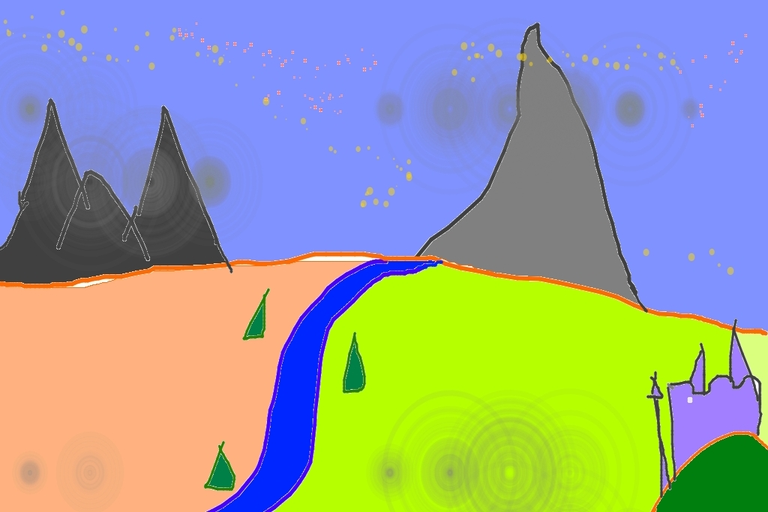

In [5]:
url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"
init_image = load_image(url).resize((768, 512))
init_image

 Experiment with the Strength Parameter

The **Strength** parameter determines how much the original image is modified.

Lower values preserve more of the original image.

Higher values generate a more dramatically changed image.


Generate the image using:

- Strength = 0.3
- Strength = 0.6
- Strength = 0.9

  0%|          | 0/15 [00:00<?, ?it/s]

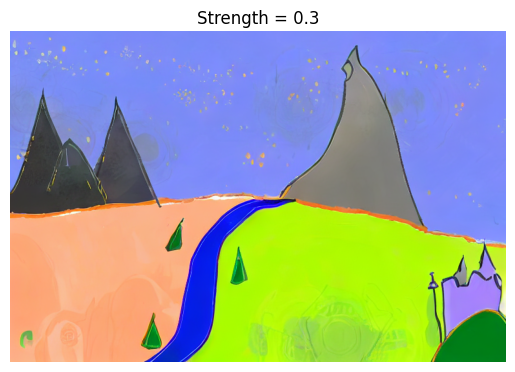

  0%|          | 0/30 [00:00<?, ?it/s]

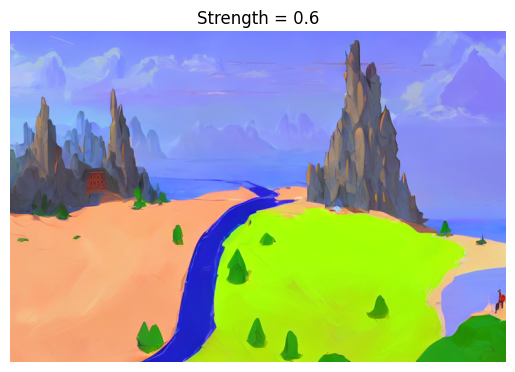

  0%|          | 0/45 [00:00<?, ?it/s]

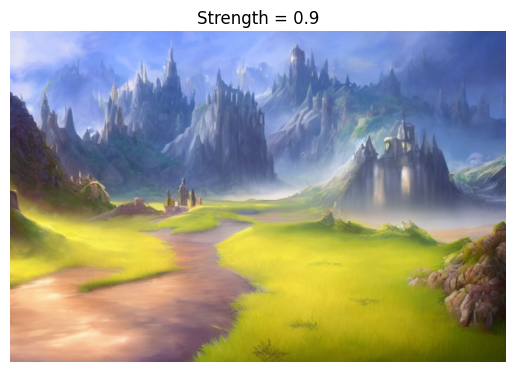

In [6]:
prompt = "a fantasy landscape, trending on artstation"

for strength in [0.3, 0.6, 0.9]:
    result = pipe_img2img(
        prompt=prompt,
        image=init_image,
        strength=strength,
        guidance_scale=7.5
    ).images[0]

    plt.imshow(result)
    plt.title(f"Strength = {strength}")
    plt.axis("off")
    plt.show()

In [7]:
print("Reflection - Strength Parameter Experiment\n")

print("1. Which strength preserved the original image best?")
print("   Strength = 0.3. It stayed closest to the original sketch, keeping the same")
print("   flat colors, layout, and shapes with only minor changes.\n")

print("2. Which strength produced the largest transformation?")
print("   Strength = 0.9. The image became almost fully reimagined - photorealistic")
print("   style, changed composition (river became a path, castle moved), and")
print("   completely different rendering.\n")

print("3. Which value would you choose if the client wanted only small edits?")
print("   Strength = 0.3. It preserves the original structure and content almost")
print("   completely, making it the safest choice for small, subtle edits.")

Reflection - Strength Parameter Experiment

1. Which strength preserved the original image best?
   Strength = 0.3. It stayed closest to the original sketch, keeping the same
   flat colors, layout, and shapes with only minor changes.

2. Which strength produced the largest transformation?
   Strength = 0.9. The image became almost fully reimagined - photorealistic
   style, changed composition (river became a path, castle moved), and
   completely different rendering.

3. Which value would you choose if the client wanted only small edits?
   Strength = 0.3. It preserves the original structure and content almost
   completely, making it the safest choice for small, subtle edits.


#  Inpainting

Instead of changing the whole image, Inpainting edits only the masked region.

The white region of the mask is regenerated.

The black region remains unchanged.

Load the Inpainting Pipeline


Complete the code below.

In [8]:
from diffusers import StableDiffusionInpaintPipeline

pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
)

pipe_inpaint = pipe_inpaint.to("cuda")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Load an image and its mask.

The mask is white where you want new content generated, and black where the original should stay untouched.

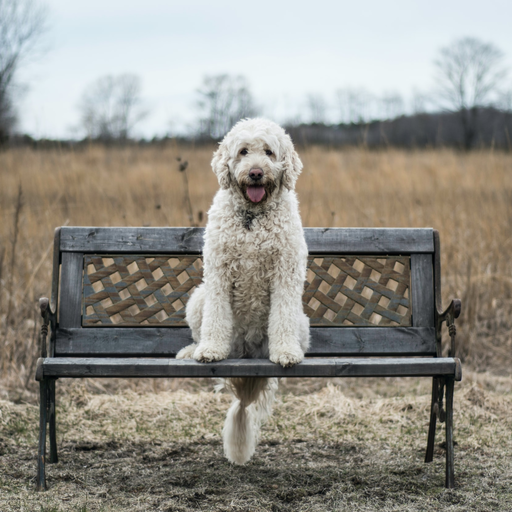

In [9]:
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

init_image = load_image(img_url).resize((512, 512))
mask_image = load_image(mask_url).resize((512, 512))

init_image

 Regenerate the masked region.

 **prompt =** "a majestic tiger sitting on a bench"

  0%|          | 0/50 [00:00<?, ?it/s]

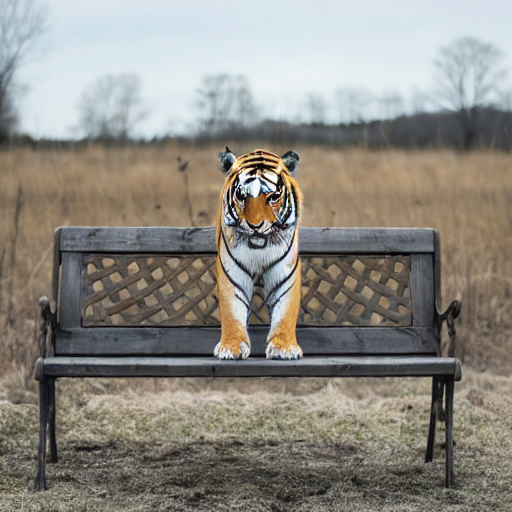

In [10]:
prompt = "a majestic tiger sitting on a bench"

result = pipe_inpaint(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image,
    guidance_scale=7.5
).images[0]

result

##**Discussion**
    • Does the edited region blend naturally with the rest of the image?
    • What happens if you make the prompt vague vs. very specific?

In [11]:
print("Discussion - Inpainting\n")

print("Does the edited region blend naturally with the rest of the image?")
print("   Yes, very naturally. The tiger's lighting, shadows, and color tone match")
print("   the overcast outdoor scene well. The bench, dry grass field, and trees")
print("   in the background remain completely untouched, and the mask boundary")
print("   around the tiger's body is nearly seamless with no visible edge line.\n")

print("What happens if you make the prompt vague vs. very specific?")
print("   A vague prompt (e.g. 'an animal') would give the model too much freedom -")
print("   it might generate something with the wrong pose, size, or lighting that")
print("   clashes with the bench and field. Because the prompt here was specific")
print("   ('a majestic tiger sitting on a bench'), the model generated an animal")
print("   correctly scaled and positioned to match the original dog's pose,")
print("   which is why the result blends so convincingly.")

Discussion - Inpainting

Does the edited region blend naturally with the rest of the image?
   Yes, very naturally. The tiger's lighting, shadows, and color tone match
   the overcast outdoor scene well. The bench, dry grass field, and trees
   in the background remain completely untouched, and the mask boundary
   around the tiger's body is nearly seamless with no visible edge line.

What happens if you make the prompt vague vs. very specific?
   A vague prompt (e.g. 'an animal') would give the model too much freedom -
   it might generate something with the wrong pose, size, or lighting that
   clashes with the bench and field. Because the prompt here was specific
   ('a majestic tiger sitting on a bench'), the model generated an animal
   correctly scaled and positioned to match the original dog's pose,
   which is why the result blends so convincingly.


 # **ControlNet**

 Install and load ControlNet

In [12]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

pipe_cn = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.45GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Create a Canny edge map from a reference image

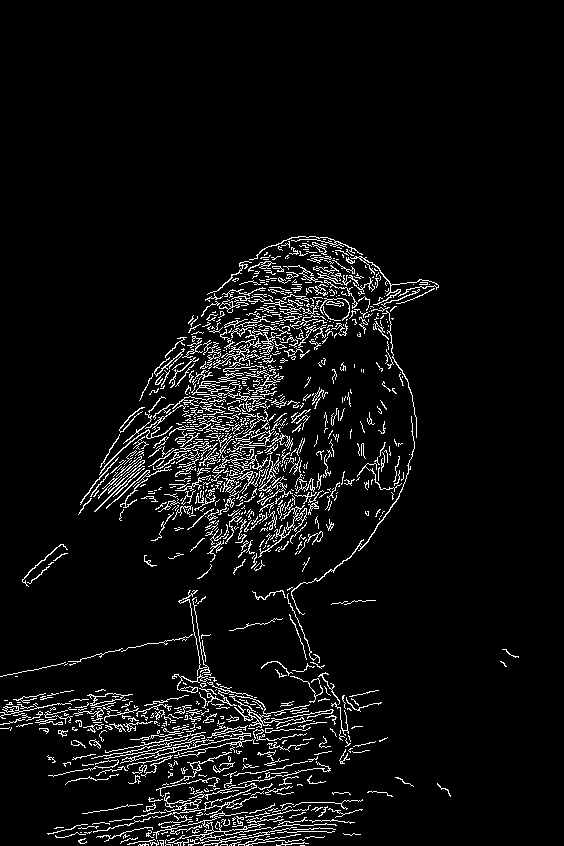

In [13]:
url = "https://huggingface.co/lllyasviel/sd-controlnet-canny/resolve/main/images/bird.png"
ref_image = load_image(url)

image_np = np.array(ref_image)

edges = cv2.Canny(image_np, 100, 200)

edges = edges[:, :, None]
edges = np.concatenate([edges, edges, edges], axis=2)

canny_image = Image.fromarray(edges)
canny_image

Generate guided by the edge map.

prompt = "a colorful parrot, highly detailed, studio lighting"

  0%|          | 0/30 [00:00<?, ?it/s]

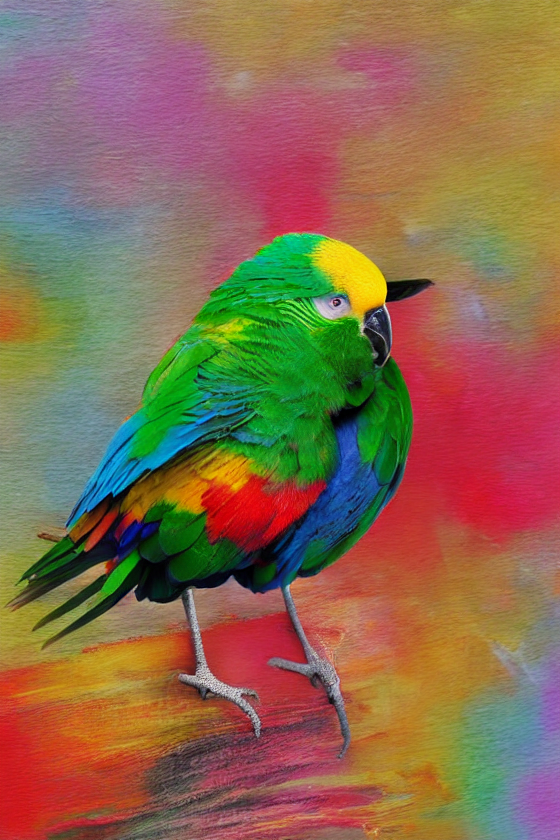

In [14]:
prompt = "a colorful parrot, highly detailed, studio lighting"

result = pipe_cn(
    prompt=prompt,
    image=canny_image,
    guidance_scale=7.5,
    num_inference_steps=30
).images[0]

result

# **Text-to-Video Exploration**

Load a lightweight text-to-video model

In [15]:
from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler

pipe_video = DiffusionPipeline.from_pretrained(
    "damo-vilab/text-to-video-ms-1.7b",
    torch_dtype=torch.float16,
    variant="fp16"
)
pipe_video.scheduler = DPMSolverMultistepScheduler.from_config(pipe_video.scheduler.config)
pipe_video.enable_model_cpu_offload()

model_index.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


Generate a short clip

In [16]:
prompt = "a golden retriever running on a beach at sunset"

video_frames = pipe_video(prompt, num_inference_steps=25).frames[0]
video_path = export_to_video(video_frames)
video_path

  0%|          | 0/25 [00:00<?, ?it/s]

'/tmp/tmp_c6aoexk.mp4'

Download the file from the Colab file browser (folder icon on the left) to watch it, or display it inline:

In [17]:
from IPython.display import Video
Video(video_path, embed=True)

Compare against a hosted demo.

Try the same prompt on one public text-to-video demo (e.g. a Hugging Face Space).

Note differences in quality, duration, and consistency.
# **Discussion**
    • How does video generation time compare to a single image?
    • What inconsistencies or artifacts do you notice across frames?

In [18]:
print("Discussion - Text-to-Video\n")

print("How does video generation time compare to a single image?")
print("   Video generation took noticeably longer than a single image (~28 seconds")
print("   for 25 steps here vs a few seconds for a single img2img/ControlNet image).")
print("   This is because the model has to generate and keep multiple frames")
print("   temporally consistent with each other, not just spatially coherent within")
print("   one frame - so compute scales with both steps AND frame count.\n")

print("What inconsistencies or artifacts do you notice across frames?")
print("   The clip shows visible flickering and texture instability in the background")
print("   (waves and sky shift inconsistently frame to frame). There's also a")
print("   'Shutterstock' watermark artifact baked into the video, which happens")
print("   because the training data likely included watermarked stock footage that")
print("   the model partially memorized. Motion also looks slightly less coherent")
print("   than a real video - the dog's running motion has some jitter/warping")
print("   compared to smooth real-world footage.")

Discussion - Text-to-Video

How does video generation time compare to a single image?
   Video generation took noticeably longer than a single image (~28 seconds
   for 25 steps here vs a few seconds for a single img2img/ControlNet image).
   This is because the model has to generate and keep multiple frames
   temporally consistent with each other, not just spatially coherent within
   one frame - so compute scales with both steps AND frame count.

What inconsistencies or artifacts do you notice across frames?
   The clip shows visible flickering and texture instability in the background
   (waves and sky shift inconsistently frame to frame). There's also a
   'Shutterstock' watermark artifact baked into the video, which happens
   because the training data likely included watermarked stock footage that
   the model partially memorized. Motion also looks slightly less coherent
   than a real video - the dog's running motion has some jitter/warping
   compared to smooth real-world foot